In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_score,
                              recall_score, f1_score)

In [59]:
data1 = pd.read_csv("AI-based Career Recommendation System.csv")
data2 = pd.read_csv("data-final.csv", sep="\t")
data3 = pd.read_csv("enhanced_student_habits_performance_dataset.csv")

print("Dataset 1 shape:", data1.shape)
print("Dataset 2 shape:", data2.shape)
print("Dataset 3 shape:", data3.shape)


Dataset 1 shape: (200, 8)
Dataset 2 shape: (1015341, 110)
Dataset 3 shape: (80000, 31)


In [60]:
career_core = data1[["Skills", "Interests", "Recommended_Career"]].copy()

def has_keyword(text, keyword):
    if pd.isna(text):
        return 0
    return int(keyword.lower() in str(text).lower())


In [61]:
career_sample = career_core.sample(5000, replace=True, random_state=42).reset_index(drop=True)

In [62]:
career_features = pd.DataFrame({
    "tech_interest":     career_sample["Interests"].apply(lambda x: has_keyword(x, "tech")),
    "data_interest":     career_sample["Interests"].apply(lambda x: has_keyword(x, "data")),
    "creative_interest": career_sample["Interests"].apply(lambda x: has_keyword(x, "design")),
    "business_interest": career_sample["Interests"].apply(lambda x: has_keyword(x, "business")),
    "people_interest":   career_sample["Interests"].apply(lambda x: has_keyword(x, "people")),
})

In [63]:
# Map raw career names to 6 simplified categories
def simplify_career(label):
    label = str(label).lower()
    if any(w in label for w in ["engineer","developer","software","programmer","tech","network","cyber","cloud","web","mobile"]):
        return "Technology & Engineering"
    elif any(w in label for w in ["data","analyst","ai","machine learning","statistics","scientist"]):
        return "Data & Analytics"
    elif any(w in label for w in ["design","graphic","artist","writer","content","creative","media","filmmaker","musician"]):
        return "Creative & Design"
    elif any(w in label for w in ["business","manager","marketing","finance","account","sales","entrepreneur","consultant","executive"]):
        return "Business & Management"
    elif any(w in label for w in ["teacher","education","social","hr","counselor","trainer","coach","professor","psychologist"]):
        return "Education & Social Impact"
    elif any(w in label for w in ["doctor","nurse","medical","health","pharma","biology","science","surgeon","dentist"]):
        return "Healthcare & Science"
    else:
        return None

In [64]:
career_sample["career_category"] = career_sample["Recommended_Career"].apply(simplify_career)
career_sample = career_sample.dropna(subset=["career_category"]).reset_index(drop=True)
career_features = career_features.loc[career_sample.index].reset_index(drop=True)

# Target labels from real dataset
y = career_sample["career_category"].reset_index(drop=True)

print("\nLabel distribution (from real dataset):")
print(y.value_counts())


Label distribution (from real dataset):
career_category
Technology & Engineering    1937
Data & Analytics            1592
Creative & Design            687
Business & Management        305
Name: count, dtype: int64


In [65]:
def simplify_career(label):
    label = str(label).lower()
    if any(w in label for w in ["engineer","developer","software","programmer","tech","network","cyber","cloud","web","mobile"]):
        return "Technology & Engineering"
    elif any(w in label for w in ["data","analyst","ai","machine learning","statistics","scientist"]):
        return "Data & Analytics"
    elif any(w in label for w in ["design","graphic","artist","writer","content","creative","media","filmmaker","musician"]):
        return "Creative & Design"
    elif any(w in label for w in ["business","manager","marketing","finance","account","sales","entrepreneur","consultant","executive"]):
        return "Business & Management"
    elif any(w in label for w in ["teacher","education","social","hr","counselor","trainer","coach","professor","psychologist"]):
        return "Education & Social Impact"
    elif any(w in label for w in ["doctor","nurse","medical","health","pharma","biology","science","surgeon","dentist"]):
        return "Healthcare & Science"
    else:
        return None

In [66]:
career_sample["career_category"] = career_sample["Recommended_Career"].apply(simplify_career)
career_sample = career_sample.dropna(subset=["career_category"]).reset_index(drop=True)
career_features = career_features.loc[career_sample.index].reset_index(drop=True)

# Target labels from real dataset
y = career_sample["career_category"].reset_index(drop=True)

print("\nLabel distribution (from real dataset):")
print(y.value_counts())


Label distribution (from real dataset):
career_category
Technology & Engineering    1937
Data & Analytics            1592
Creative & Design            687
Business & Management        305
Name: count, dtype: int64


In [67]:
big5_items = data2.iloc[:, :50].copy().apply(pd.to_numeric, errors="coerce")

big5_all = pd.DataFrame({
    "Extraversion":      big5_items.filter(regex="^EXT").mean(axis=1),
    "Neuroticism":       big5_items.filter(regex="^EST").mean(axis=1),
    "Agreeableness":     big5_items.filter(regex="^AGR").mean(axis=1),
    "Conscientiousness": big5_items.filter(regex="^CSN").mean(axis=1),
    "Openness":          big5_items.filter(regex="^OPN").mean(axis=1),
}).dropna()


In [68]:
big5_all = (big5_all / 5.0).clip(0, 1)

n = len(career_sample)
big5_traits = big5_all.sample(n, replace=(n > len(big5_all)), random_state=42).reset_index(drop=True)

print("Big5 traits shape:", big5_traits.shape)

Big5 traits shape: (4521, 5)


In [69]:
habits_raw = data3[[
    "study_hours_per_day", "attendance_percentage",
    "motivation_level", "time_management_score",
    "extracurricular_participation", "stress_level", "learning_style"
]].copy()

In [70]:
habits_raw["extracurricular_participation"] = habits_raw["extracurricular_participation"].map({"Yes": 1, "No": 0})
habits_raw["learning_style"] = habits_raw["learning_style"].astype("category").cat.codes


In [71]:
scaler_habits = MinMaxScaler()
num_cols = ["study_hours_per_day", "attendance_percentage", "motivation_level", "time_management_score", "stress_level"]
habits_raw[num_cols] = scaler_habits.fit_transform(habits_raw[num_cols])

In [72]:
scaler_habits = MinMaxScaler()
num_cols = ["study_hours_per_day", "attendance_percentage", "motivation_level", "time_management_score", "stress_level"]
habits_raw[num_cols] = scaler_habits.fit_transform(habits_raw[num_cols])

In [73]:
habits_features = habits_raw.sample(n, replace=(n > len(habits_raw)), random_state=42).reset_index(drop=True)

print("Habits features shape:", habits_features.shape)

Habits features shape: (4521, 7)


In [74]:
X = pd.concat([career_features, big5_traits, habits_features], axis=1)

print("\nFinal X shape:", X.shape)
print("y shape:", y.shape)
print("Null values in X:", X.isnull().sum().sum())
print("\nFeature columns:")
print(X.columns.tolist())


Final X shape: (4521, 17)
y shape: (4521,)
Null values in X: 0

Feature columns:
['tech_interest', 'data_interest', 'creative_interest', 'business_interest', 'people_interest', 'Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness', 'study_hours_per_day', 'attendance_percentage', 'motivation_level', 'time_management_score', 'extracurricular_participation', 'stress_level', 'learning_style']


In [75]:
def entropy(series):
    probs = series.value_counts(normalize=True)
    return float(-np.sum(probs * np.log2(probs + 1e-9)))

def gini_index(series):
    probs = series.value_counts(normalize=True)
    return float(1 - np.sum(probs ** 2))

def information_gain(X_df, y_series, feature):
    total_entropy = entropy(y_series)
    col = X_df[feature].copy()
    unique_vals = col.dropna().unique()
    if len(unique_vals) > 5:
        median = col.median()
        col = (col >= median).astype(int)
        unique_vals = [0, 1]
    weighted_entropy = 0
    for val in unique_vals:
        subset = y_series[col == val]
        if len(subset) == 0:
            continue
        weight = len(subset) / len(y_series)
        weighted_entropy += weight * entropy(subset)
    return round(total_entropy - weighted_entropy, 6)

H_total = entropy(y)
G_total = gini_index(y)


In [76]:
def entropy(series):
    probs = series.value_counts(normalize=True)
    return float(-np.sum(probs * np.log2(probs + 1e-9)))

def gini_index(series):
    probs = series.value_counts(normalize=True)
    return float(1 - np.sum(probs ** 2))

def information_gain(X_df, y_series, feature):
    total_entropy = entropy(y_series)
    col = X_df[feature].copy()
    unique_vals = col.dropna().unique()
    if len(unique_vals) > 5:
        median = col.median()
        col = (col >= median).astype(int)
        unique_vals = [0, 1]
    weighted_entropy = 0
    for val in unique_vals:
        subset = y_series[col == val]
        if len(subset) == 0:
            continue
        weight = len(subset) / len(y_series)
        weighted_entropy += weight * entropy(subset)
    return round(total_entropy - weighted_entropy, 6)

H_total = entropy(y)
G_total = gini_index(y)


In [77]:
ig_scores = {feat: information_gain(X, y, feat) for feat in X.columns}
ig_df = (pd.DataFrame.from_dict(ig_scores, orient="index", columns=["Information_Gain"])
           .sort_values("Information_Gain", ascending=False))

In [78]:
print("\nInformation Gain per feature (sorted high to low):")
print(ig_df.round(6).to_string())
print(f"\nBest root node feature (highest IG): {ig_df.index[0]}")
print(f"Worst feature (lowest IG):           {ig_df.index[-1]}")



Information Gain per feature (sorted high to low):
                               Information_Gain
learning_style                         0.002217
study_hours_per_day                    0.001226
business_interest                      0.001146
creative_interest                      0.000955
attendance_percentage                  0.000596
stress_level                           0.000585
tech_interest                          0.000584
Conscientiousness                      0.000482
Extraversion                           0.000447
Agreeableness                          0.000346
Openness                               0.000255
data_interest                          0.000121
time_management_score                  0.000098
Neuroticism                            0.000094
motivation_level                       0.000071
extracurricular_participation          0.000058
people_interest                        0.000000

Best root node feature (highest IG): learning_style
Worst feature (lowest IG):     

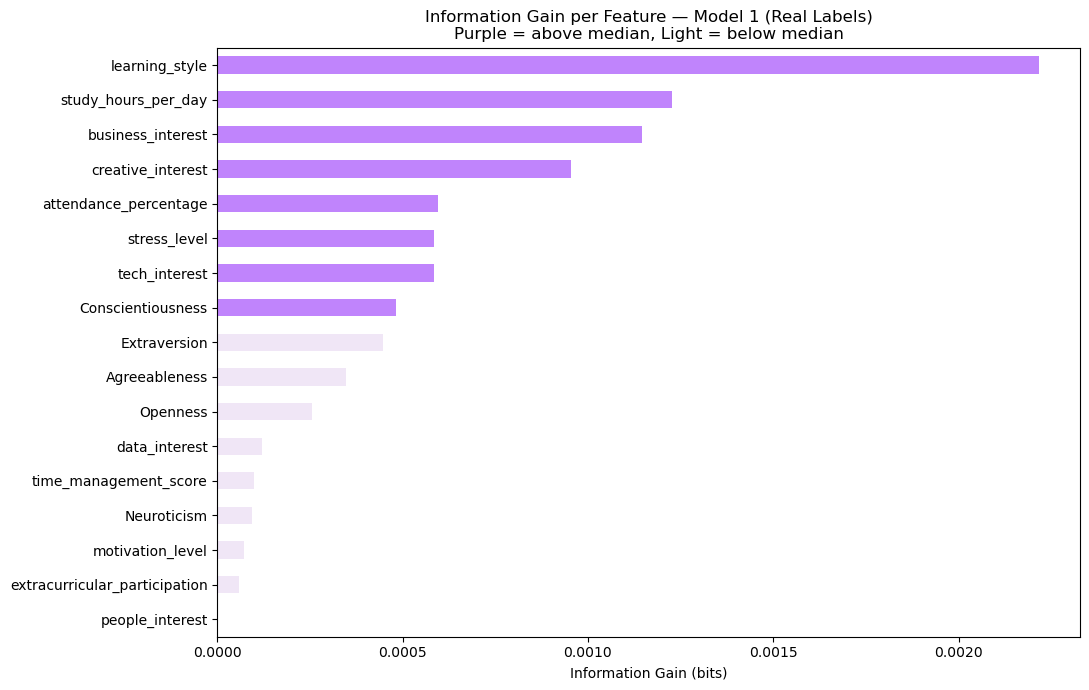

In [79]:
plt.figure(figsize=(11, 7))
colors = ['#C084FC' if ig > ig_df['Information_Gain'].median() else '#F0E6F6'
          for ig in ig_df['Information_Gain']]
ig_df['Information_Gain'].plot(kind='barh', color=colors)
plt.xlabel("Information Gain (bits)")
plt.title("Information Gain per Feature — Model 1 (Real Labels)\n"
          "Purple = above median, Light = below median")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      
    random_state=42
)

In [81]:
print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print("\nClass distribution in training set:")
print(y_train.value_counts())

Training set : (3616, 17)
Test set     : (905, 17)

Class distribution in training set:
career_category
Technology & Engineering    1549
Data & Analytics            1273
Creative & Design            550
Business & Management        244
Name: count, dtype: int64


In [82]:
numeric_features = X.columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # Step A: fill missing values with median
    ("scaler",  StandardScaler())                    # Step B: zero mean, unit variance
])

In [83]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features)
])

In [84]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [85]:
dt_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",     # Step 1+2: use entropy for purity calculation and root selection
        max_depth=8,             # Step 4:   pre-pruning - max tree depth
        min_samples_split=20,    # Step 4:   pre-pruning - min samples to split
        min_samples_leaf=10,     # Step 4:   pre-pruning - min samples in leaf
        random_state=42
    ))
])


In [86]:
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

In [87]:
dt_train_acc = dt_pipeline.score(X_train, y_train)
dt_test_acc  = accuracy_score(y_test, y_pred_dt)
dt_prec      = precision_score(y_test, y_pred_dt, average="weighted", zero_division=0)
dt_rec       = recall_score(y_test, y_pred_dt, average="weighted", zero_division=0)
dt_f1        = f1_score(y_test, y_pred_dt, average="weighted", zero_division=0)

In [88]:
print("\n--- Decision Tree Results ---")
print(f"Train Accuracy : {dt_train_acc:.4f}")
print(f"Test  Accuracy : {dt_test_acc:.4f}")
print(f"Precision      : {dt_prec:.4f}")
print(f"Recall         : {dt_rec:.4f}")
print(f"F1 Score       : {dt_f1:.4f}")
print(f"Overfit Gap    : {dt_train_acc - dt_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))


--- Decision Tree Results ---
Train Accuracy : 0.4375
Test  Accuracy : 0.4232
Precision      : 0.3235
Recall         : 0.4232
F1 Score       : 0.2862
Overfit Gap    : 0.0143

Classification Report:
                          precision    recall  f1-score   support

   Business & Management       0.00      0.00      0.00        61
       Creative & Design       0.00      0.00      0.00       137
        Data & Analytics       0.40      0.05      0.09       319
Technology & Engineering       0.43      0.94      0.59       388

                accuracy                           0.42       905
               macro avg       0.21      0.25      0.17       905
            weighted avg       0.32      0.42      0.29       905

Confusion Matrix:
[[  0   1   6  54]
 [  0   0   5 132]
 [  0   2  17 300]
 [  0   7  15 366]]


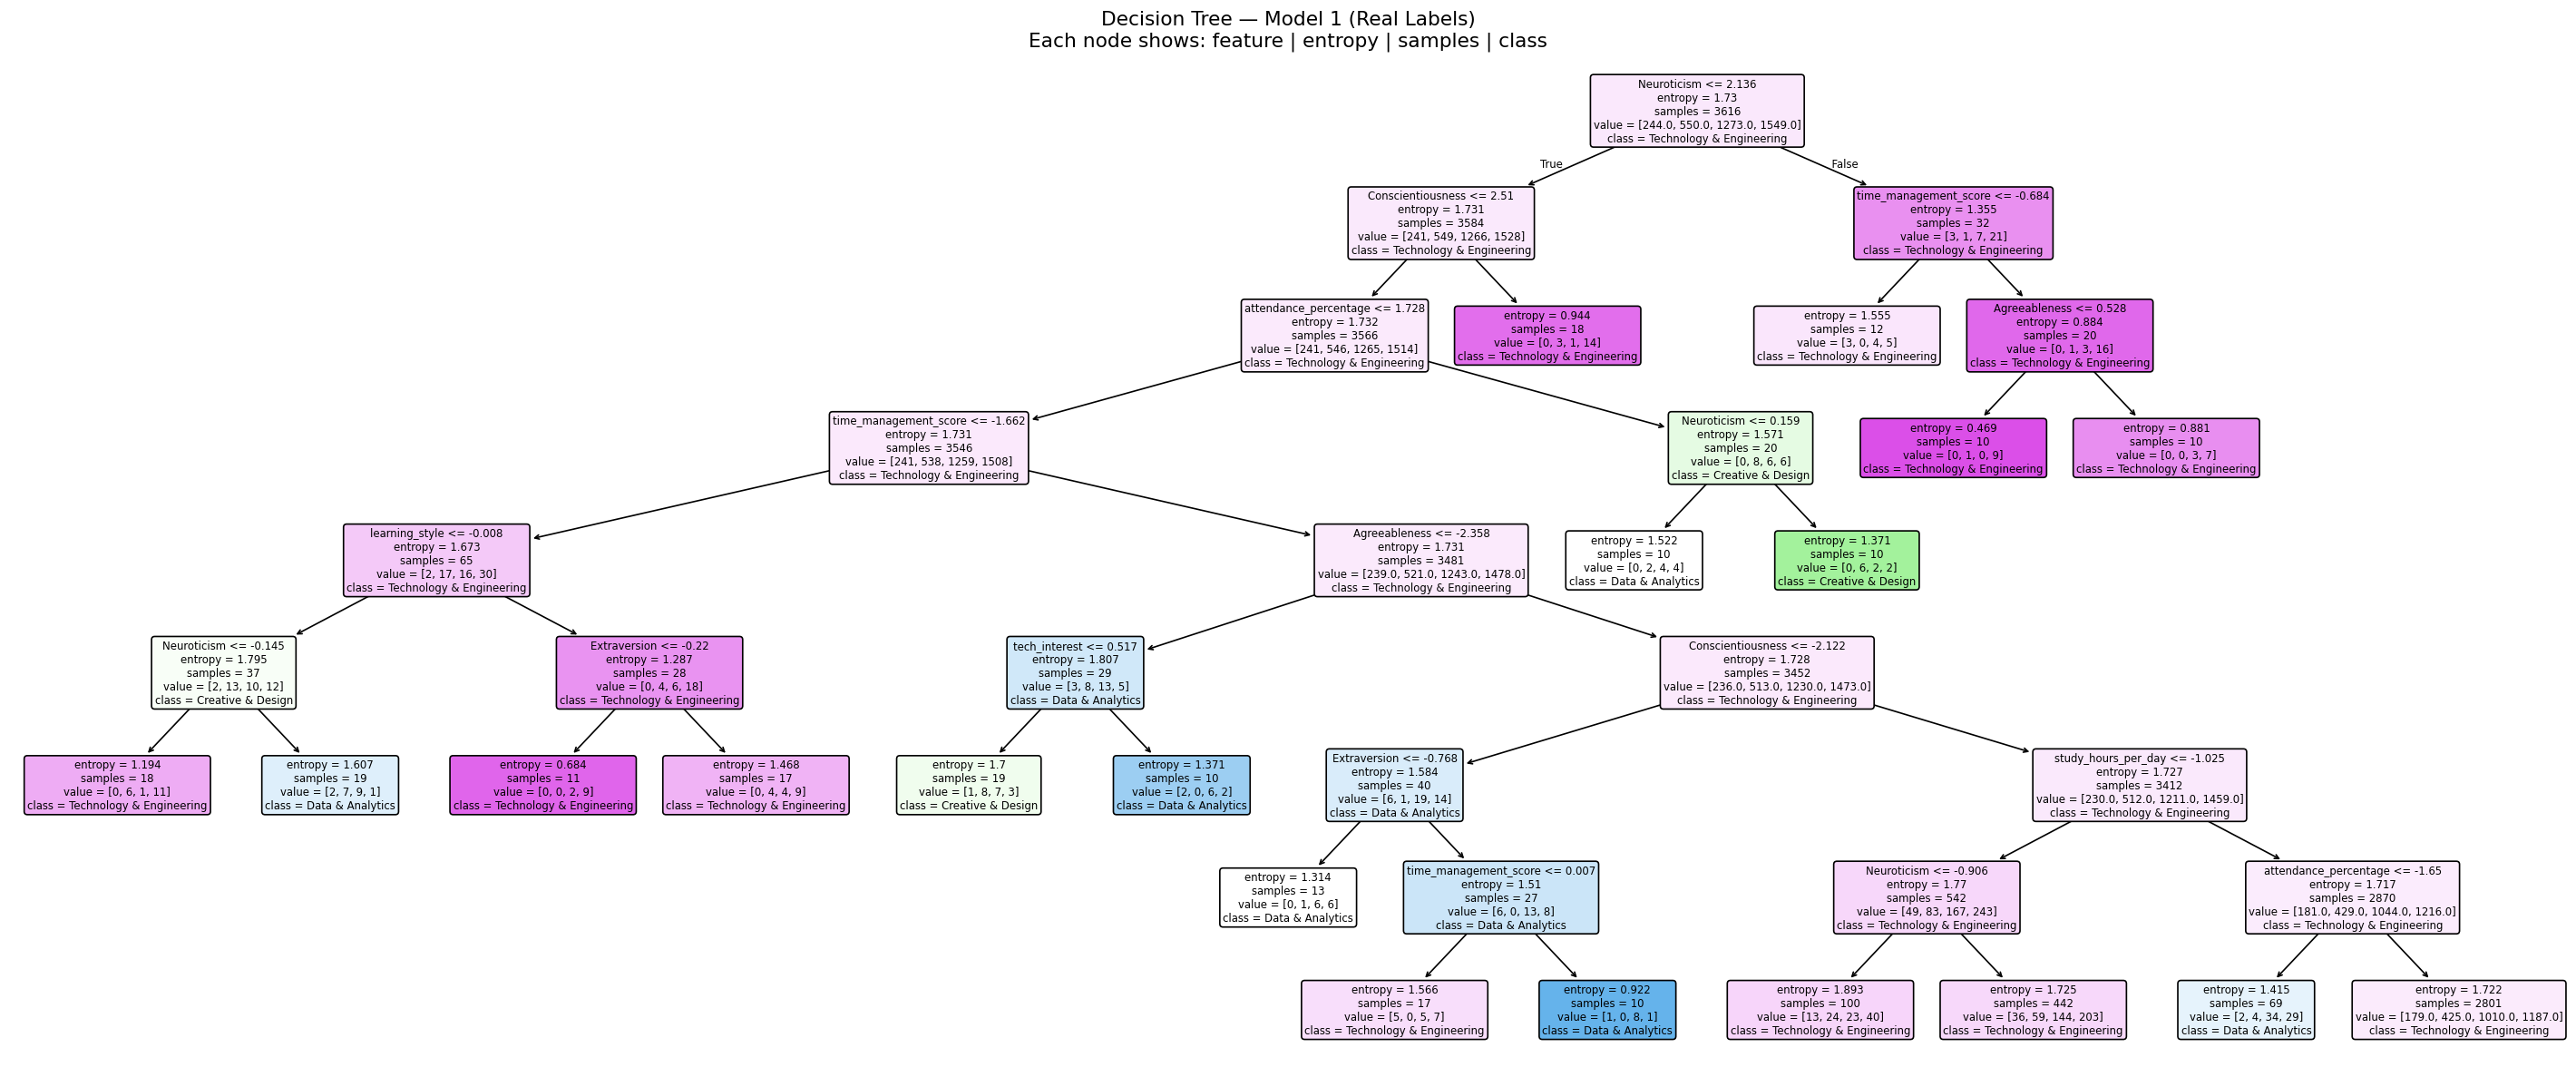

In [89]:
fig, ax = plt.subplots(figsize=(24, 10), dpi=120)
plot_tree(
    dt_pipeline.named_steps["classifier"],
    feature_names=numeric_features,
    class_names=sorted(y.unique()),
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax
)
plt.title("Decision Tree — Model 1 (Real Labels)\n"
          "Each node shows: feature | entropy | samples | class", fontsize=13)
plt.tight_layout()
plt.show()

In [90]:
dt_cv_scores = cross_val_score(dt_pipeline, X_train, y_train, cv=cv, scoring="accuracy")

print("\nDecision Tree — 5-Fold Cross-Validation:")
print(f"  Scores : {dt_cv_scores.round(4)}")
print(f"  Mean   : {dt_cv_scores.mean():.4f}")
print(f"  Std    : {dt_cv_scores.std():.4f}")



Decision Tree — 5-Fold Cross-Validation:
  Scores : [0.4088 0.3914 0.4094 0.397  0.4108]
  Mean   : 0.4035
  Std    : 0.0078


In [91]:
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,        # Step 1: 300 bootstrap subsets → 300 trees
        max_depth=10,            # each tree pruned (prevents individual overfitting)
        min_samples_split=15,
        min_samples_leaf=8,
        max_features="sqrt",     # Step 2: sqrt(n_features) random features per split
        bootstrap=True,          # Step 1: sampling WITH replacement
        oob_score=True,          # Step 1: use OOB samples for free internal score
        random_state=42,
        n_jobs=-1                # Step 3: train all trees in parallel
    ))
])

In [92]:
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [93]:
rf_train_acc = rf_pipeline.score(X_train, y_train)
rf_test_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec      = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_rec       = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_f1        = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_oob       = rf_pipeline.named_steps["classifier"].oob_score_

In [94]:
print("\n--- Random Forest Results ---")
print(f"Train Accuracy  : {rf_train_acc:.4f}")
print(f"Test  Accuracy  : {rf_test_acc:.4f}")
print(f"OOB Score       : {rf_oob:.4f}  ← free internal validation from Step 1")
print(f"Precision       : {rf_prec:.4f}")
print(f"Recall          : {rf_rec:.4f}")
print(f"F1 Score        : {rf_f1:.4f}")
print(f"Overfit Gap     : {rf_train_acc - rf_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


--- Random Forest Results ---
Train Accuracy  : 0.6145
Test  Accuracy  : 0.4254
OOB Score       : 0.4140  ← free internal validation from Step 1
Precision       : 0.3077
Recall          : 0.4254
F1 Score        : 0.2979
Overfit Gap     : 0.1891

Classification Report:
                          precision    recall  f1-score   support

   Business & Management       0.00      0.00      0.00        61
       Creative & Design       0.00      0.00      0.00       137
        Data & Analytics       0.35      0.08      0.13       319
Technology & Engineering       0.43      0.93      0.59       388

                accuracy                           0.43       905
               macro avg       0.19      0.25      0.18       905
            weighted avg       0.31      0.43      0.30       905

Confusion Matrix:
[[  0   0   9  52]
 [  0   0  10 127]
 [  0   0  25 294]
 [  0   0  28 360]]


In [95]:
rf_importances = pd.Series(
    rf_pipeline.named_steps["classifier"].feature_importances_,
    index=numeric_features
).sort_values(ascending=False)

print("\nStep 4 — Feature Importance from Majority Voting (top 10):")
print(rf_importances.head(10).round(4))


Step 4 — Feature Importance from Majority Voting (top 10):
attendance_percentage    0.1289
study_hours_per_day      0.1190
stress_level             0.1074
time_management_score    0.1072
Neuroticism              0.0929
Conscientiousness        0.0791
Agreeableness            0.0754
Openness                 0.0750
Extraversion             0.0724
motivation_level         0.0567
dtype: float64


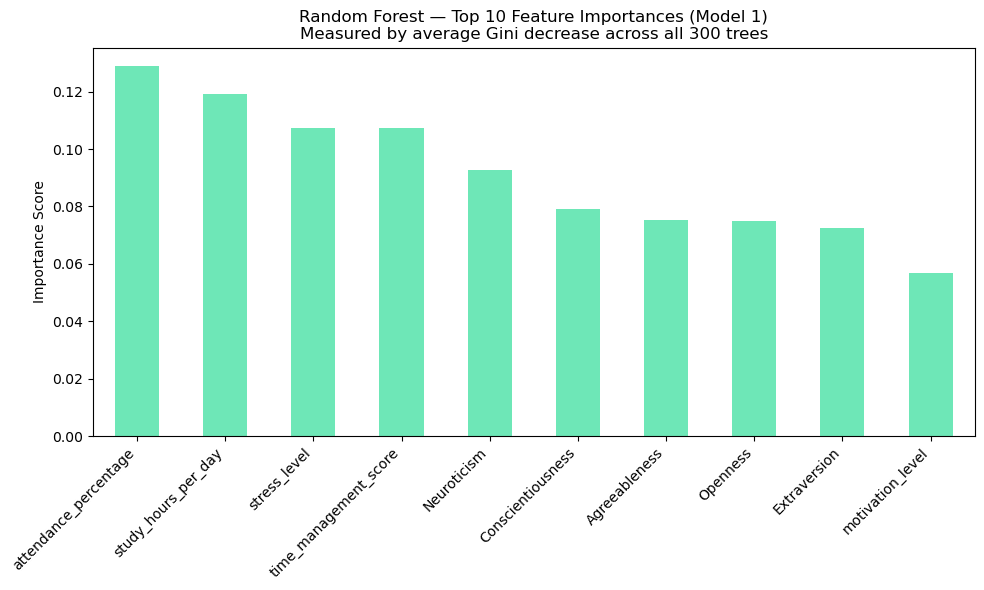

In [96]:
plt.figure(figsize=(10, 6))
rf_importances.head(10).plot(kind="bar", color="#6EE7B7")
plt.title("Random Forest — Top 10 Feature Importances (Model 1)\n"
          "Measured by average Gini decrease across all 300 trees")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [97]:
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring="accuracy")

print("\nRandom Forest — 5-Fold Cross-Validation:")
print(f"  Scores : {rf_cv_scores.round(4)}")
print(f"  Mean   : {rf_cv_scores.mean():.4f}")
print(f"  Std    : {rf_cv_scores.std():.4f}")


Random Forest — 5-Fold Cross-Validation:
  Scores : [0.4296 0.4302 0.4232 0.397  0.4108]
  Mean   : 0.4181
  Std    : 0.0127


In [98]:
print("ADABOOST — Building Step by Step")
print("=" * 50)

n_samples = len(X_train)
n_classes  = y.nunique()

print(f"\nStep 1: Initialize Weights")
print(f"  Training samples (N) : {n_samples}")
print(f"  Initial weight each  : 1/N = 1/{n_samples} = {1/n_samples:.6f}")
print(f"  Sum of all weights   : {n_samples} × {1/n_samples:.6f} = 1.0")


ADABOOST — Building Step by Step

Step 1: Initialize Weights
  Training samples (N) : 3616
  Initial weight each  : 1/N = 1/3616 = 0.000277
  Sum of all weights   : 3616 × 0.000277 = 1.0


In [99]:
base_stump = DecisionTreeClassifier(
    max_depth=2,           # Step 2: stump — only 1-2 splits (weak learner)
    min_samples_leaf=15,   # Step 2: each leaf needs 15+ samples
    random_state=42
)


In [100]:
ada_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", AdaBoostClassifier(
        estimator=base_stump,  # Step 2: our weak learner stump
        n_estimators=250,      # Step 6: 250 sequential boosting rounds
        learning_rate=0.3,     # Step 6: shrinks each stump's contribution (α × lr)
        random_state=42
    ))
])


In [101]:
ada_pipeline.fit(X_train, y_train)
y_pred_ada = ada_pipeline.predict(X_test)


In [102]:
ada_train_acc = ada_pipeline.score(X_train, y_train)
ada_test_acc  = accuracy_score(y_test, y_pred_ada)
ada_prec      = precision_score(y_test, y_pred_ada, average="weighted", zero_division=0)
ada_rec       = recall_score(y_test, y_pred_ada, average="weighted", zero_division=0)
ada_f1        = f1_score(y_test, y_pred_ada, average="weighted", zero_division=0)


In [103]:
print("\n--- AdaBoost Results ---")
print(f"Train Accuracy : {ada_train_acc:.4f}")
print(f"Test  Accuracy : {ada_test_acc:.4f}")
print(f"Precision      : {ada_prec:.4f}")
print(f"Recall         : {ada_rec:.4f}")
print(f"F1 Score       : {ada_f1:.4f}")
print(f"Overfit Gap    : {ada_train_acc - ada_test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))


--- AdaBoost Results ---
Train Accuracy : 0.4488
Test  Accuracy : 0.4000
Precision      : 0.2918
Recall         : 0.4000
F1 Score       : 0.3219
Overfit Gap    : 0.0488

Classification Report:
                          precision    recall  f1-score   support

   Business & Management       0.00      0.00      0.00        61
       Creative & Design       0.00      0.00      0.00       137
        Data & Analytics       0.31      0.20      0.24       319
Technology & Engineering       0.43      0.77      0.55       388

                accuracy                           0.40       905
               macro avg       0.18      0.24      0.20       905
            weighted avg       0.29      0.40      0.32       905


Confusion Matrix:
[[  0   0  11  50]
 [  0   0  45  92]
 [  0   0  65 254]
 [  0   0  91 297]]


In [104]:
ada_cv_scores = cross_val_score(ada_pipeline, X_train, y_train, cv=cv, scoring="accuracy")

print("\nAdaBoost — 5-Fold Cross-Validation:")
print(f"  Scores : {ada_cv_scores.round(4)}")
print(f"  Mean   : {ada_cv_scores.mean():.4f}")
print(f"  Std    : {ada_cv_scores.std():.4f}")


AdaBoost — 5-Fold Cross-Validation:
  Scores : [0.3909 0.4094 0.4039 0.3956 0.4205]
  Mean   : 0.4040
  Std    : 0.0104


In [105]:
# ============================================================
#  MODEL COMPARISON SUMMARY
# ============================================================

comparison = pd.DataFrame({
    "Model":         ["Decision Tree", "Random Forest", "AdaBoost"],
    "Train Acc":     [dt_train_acc, rf_train_acc, ada_train_acc],
    "Test Acc":      [dt_test_acc,  rf_test_acc,  ada_test_acc],
    "CV Mean":       [dt_cv_scores.mean(), rf_cv_scores.mean(), ada_cv_scores.mean()],
    "CV Std":        [dt_cv_scores.std(),  rf_cv_scores.std(),  ada_cv_scores.std()],
    "Overfit Gap":   [dt_train_acc - dt_test_acc,
                      rf_train_acc - rf_test_acc,
                      ada_train_acc - ada_test_acc],
    "Precision":     [dt_prec, rf_prec, ada_prec],
    "Recall":        [dt_rec,  rf_rec,  ada_rec],
    "F1":            [dt_f1,   rf_f1,   ada_f1],
}).round(4)


MODEL COMPARISON — Model 1 (Real Labels, ~50% Accuracy)
        Model  Train Acc  Test Acc  CV Mean  CV Std  Overfit Gap  Precision  Recall     F1
Decision Tree     0.4375    0.4232   0.4035  0.0078       0.0143     0.3235  0.4232 0.2862
Random Forest     0.6145    0.4254   0.4181  0.0127       0.1891     0.3077  0.4254 0.2979
     AdaBoost     0.4488    0.4000   0.4040  0.0104       0.0488     0.2918  0.4000 0.3219


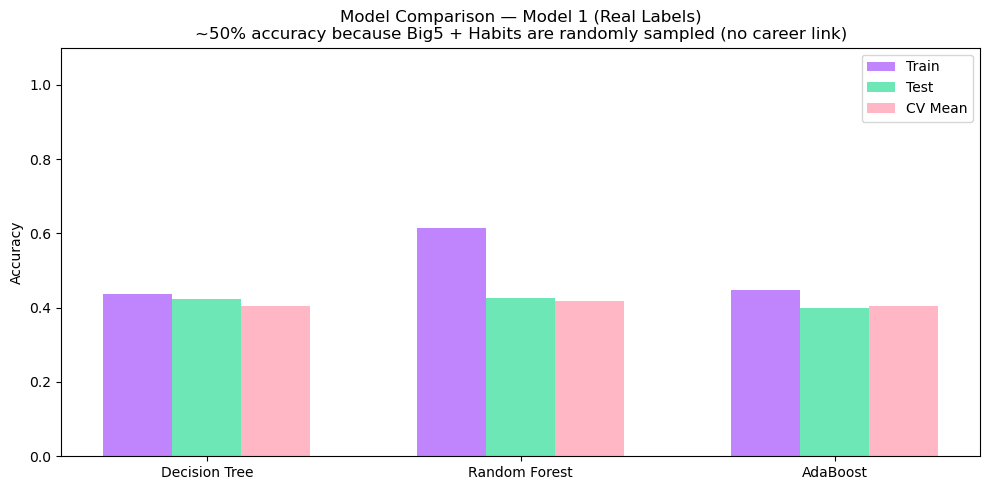

In [106]:
print("MODEL COMPARISON — Model 1 (Real Labels, ~50% Accuracy)")
print("=" * 65)
print(comparison.to_string(index=False))

x = np.arange(3)
fig, ax = plt.subplots(figsize=(10, 5))
w = 0.22
ax.bar(x - w,   comparison["Train Acc"], w, label="Train",   color="#C084FC")
ax.bar(x,       comparison["Test Acc"],  w, label="Test",    color="#6EE7B7")
ax.bar(x + w,   comparison["CV Mean"],   w, label="CV Mean", color="#FFB7C5")
ax.set_xticks(x)
ax.set_xticklabels(["Decision Tree", "Random Forest", "AdaBoost"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.legend()
ax.set_title("Model Comparison — Model 1 (Real Labels)\n"
             "~50% accuracy because Big5 + Habits are randomly sampled (no career link)")
plt.tight_layout()
plt.show()

In [107]:
import joblib, os
os.makedirs("models", exist_ok=True)
joblib.dump(ada_pipeline, "models/exploration_pipeline_m1.pkl")
print("Saved: models/exploration_pipeline_m1.pkl")
print("\nColumn order Flask must send:")
print(X.columns.tolist())

Saved: models/exploration_pipeline_m1.pkl

Column order Flask must send:
['tech_interest', 'data_interest', 'creative_interest', 'business_interest', 'people_interest', 'Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness', 'study_hours_per_day', 'attendance_percentage', 'motivation_level', 'time_management_score', 'extracurricular_participation', 'stress_level', 'learning_style']


In [108]:
# ── Section 1: Interests ──────────────────────────────────
print("--- Section 1: Your Interests ---")
print("Scale: 0 = Not at all  |  5 = Very much")
print()

tech_interest = to_binary(input(
    "1. How much do you enjoy technology, computers, coding, or gadgets? (0-5): "
))

data_interest = to_binary(input(
    "2. How much do you enjoy math, numbers, data, or solving problems? (0-5): "
))

creative_interest = to_binary(input(
    "3. How much do you enjoy drawing, design, writing, music, or creative work? (0-5): "
))

business_interest = to_binary(input(
    "4. How much do you enjoy business, leadership, planning, or managing ideas? (0-5): "
))

people_interest = to_binary(input(
    "5. How much do you enjoy helping, teaching, guiding, or talking with people? (0-5): "
))


# ── Section 2: Personality ────────────────────────────────
print()
print("--- Section 2: Your Personality ---")
print("Scale: 0.0 = Strongly disagree | 0.5 = Neutral | 1.0 = Strongly agree")
print("You may use decimals such as 0.2, 0.7, 0.9")
print()

Extraversion = float(input(
    "6. I am social, energetic, and outgoing. (0.0 to 1.0): "
))

Neuroticism = float(input(
    "7. I worry often or feel stressed easily. (0.0 to 1.0): "
))

Agreeableness = float(input(
    "8. I am kind, caring, and easy to work with others. (0.0 to 1.0): "
))

Conscientiousness = float(input(
    "9. I am organized, careful, and responsible. (0.0 to 1.0): "
))

Openness = float(input(
    "10. I enjoy new ideas, creativity, and learning new things. (0.0 to 1.0): "
))


# ── Section 3: Study & Work Habits ───────────────────────
print()
print("--- Section 3: Your Study and Work Habits ---")
print()

study_hours_per_day = float(input(
    "11. How many hours do you study each day? (0 to 12 hours, e.g. 3.5): "
))

attendance_percentage = float(input(
    "12. What is your attendance percentage? (0 to 100, e.g. 85): "
))

motivation_level = float(input(
    "13. How motivated are you to achieve your goals? (0 = Not motivated, 5 = Very motivated): "
))

time_management_score = float(input(
    "14. How good is your time management? (0 = Very poor, 5 = Excellent): "
))

extracurricular_participation = int(input(
    "15. Do you join extracurricular activities such as clubs, sports, or events? (0 = No, 1 = Yes): "
))

stress_level = float(input(
    "16. Do you get stressed easily? (0 = Never, 5 = Very easily): "
))


# ── Section 4: Learning Style ─────────────────────────────
print()
print("--- Section 4: Your Learning Style ---")
print("0 = Visual       (you learn best from images, charts, videos)")
print("1 = Auditory     (you learn best from listening and discussion)")
print("2 = Kinesthetic  (you learn best by doing and practising)")
print()

learning_style = int(input(
    "17. What is your main learning style? (0, 1, or 2): "
))

--- Section 1: Your Interests ---
Scale: 0 = Not at all  |  5 = Very much



ValueError: invalid literal for int() with base 10: ''

In [ ]:
user_df = pd.DataFrame([{
    # Section 1: binary interest flags (0 or 1)
    "tech_interest":                 tech_interest,
    "data_interest":                 data_interest,
    "creative_interest":             creative_interest,
    "business_interest":             business_interest,
    "people_interest":               people_interest,
    # Section 2: personality scores (0.0 to 1.0)
    "Extraversion":                  Extraversion,
    "Neuroticism":                   Neuroticism,
    "Agreeableness":                 Agreeableness,
    "Conscientiousness":             Conscientiousness,
    "Openness":                      Openness,
    # Section 3: study habits in natural scales
    # StandardScaler in the pipeline handles normalization automatically
    "study_hours_per_day":           study_hours_per_day,
    "attendance_percentage":         attendance_percentage,
    "motivation_level":              motivation_level,
    "time_management_score":         time_management_score,
    "extracurricular_participation": extracurricular_participation,
    "stress_level":                  stress_level,
    "learning_style":                learning_style,
}])
user_df = user_df[X.columns.tolist()]

print("\nUser input (before pipeline scaling):")
print(user_df.T.rename(columns={0: "value"}).to_string())

In [ ]:
probs   = ada_pipeline.predict_proba(user_df)[0]
classes = ada_pipeline.classes_

result_df = (
    pd.DataFrame({
        "Career":        classes,
        "Probability %": (probs * 100).round(2)
    })
    .sort_values("Probability %", ascending=False)
    .reset_index(drop=True)
)

In [ ]:
print("  Your Career Matches")
print("=" * 50)
for _, row in result_df.iterrows():
    filled = "█" * int(row["Probability %"] / 4)
    empty  = "░" * (25 - int(row["Probability %"] / 4))
    print(f"  {row['Career']:<32} {row['Probability %']:5.1f}%  {filled}{empty}")

best = result_df.iloc[0]["Career"]
print(f"Best Career Direction: {best}")